In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense , Dropout




In [3]:
from sklearn.model_selection import train_test_split

In [39]:
%pwd

'/Users/aashuanand/AI-Powered-Precision-Agriculture-Monitoring-System/notebooks'

In [40]:
test1 = pd.read_csv("../data/raw/test1.csv")
test1['date'] = pd.to_datetime(test1['date'])

test1 = test1.sort_values(['lat', 'lon', 'date'])

In [2]:
df = pd.read_csv("../data/raw/Data.csv")
df['date'] = pd.to_datetime(df['date'])

df = df.sort_values(['lat', 'lon', 'date'])

df.head()

,system:index,B11,B12,B2,B3,B4,B8,NDVI,NDWI,date,lat,lon,.geo
2,20230102T054231_20230102T054230_T43RDP_14_0,2704,2187,1338,1679,1621,2962,0.292603,-0.276449,2023-01-02,30.000515,74.18055,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
13,20230117T054149_20230117T054149_T43RDP_14_0,2497,1947,1471,1691,1504,3338,0.378769,-0.327501,2023-01-17,30.000515,74.18055,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
97,20230127T054109_20230127T054834_T43RDP_14_0,2447,1832,1372,1578,1375,4008,0.489132,-0.435016,2023-01-27,30.000515,74.18055,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
149,20230201T054041_20230201T054044_T43RDP_14_0,2383,1699,1281,1531,1296,4188,0.527352,-0.464592,2023-02-01,30.000515,74.18055,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
193,20230206T054019_20230206T054847_T43RDP_14_0,2549,1864,1218,1472,1260,4652,0.573748,-0.519268,2023-02-06,30.000515,74.18055,"{""geodesic"":false,""type"":""Point"",""coordinates""..."


In [6]:
df_train,df_test=train_test_split(df,test_size=0.2,random_state=42)
df_train.shape

(1356, 13)

In [19]:
# Split by date (better than random)
split_date = df['date'].quantile(0.8)

df_train = df[df['date'] <= split_date]
df_test  = df[df['date'] > split_date]

print(df_train.shape, df_test.shape)

(1378, 13) (318, 13)


In [20]:
# Split by date (better than random)
split_date = df_train['date'].quantile(0.8)

df_val  = df_train[df_train['date'] > split_date]
df_train = df_train[df_train['date'] <= split_date]


print(df_train.shape, df_val.shape)

(1104, 13) (274, 13)


In [21]:
def create_sequences_all(df, seq_length=5):
    X, y = [], []

    for (lat, lon), group in df.groupby(['lat', 'lon']):
        group = group.sort_values('date')
        ndvi = group['NDVI'].values

        for i in range(len(ndvi) - seq_length):
            X.append(ndvi[i:i+seq_length])
            y.append(ndvi[i+seq_length])

    return np.array(X), np.array(y)


In [41]:
seq_length = 10
X_test1, y_test1 = create_sequences_all(test1, seq_length)
X_test1  = X_test1.reshape((X_test1.shape[0], X_test1.shape[1], 1))
print(X_test1.shape)

(140, 10, 1)


In [43]:
y_test1.shape

(140,)

In [22]:
seq_length = 10

X_train, y_train = create_sequences_all(df_train, seq_length)
X_test, y_test   = create_sequences_all(df_test, seq_length)
X_val, y_val   = create_sequences_all(df_val, seq_length)

# reshape
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test  = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))
X_val  = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))

print(X_train.shape, X_test.shape)

(610, 10, 1) (62, 10, 1)


In [23]:
y_train.shape

(610,)

In [64]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    
    # Layer 1
    LSTM(64, return_sequences=True, input_shape=(seq_length, 1)),
    Dropout(0.2),

    # Layer 2
    LSTM(64, return_sequences=False),
    Dropout(0.2),

    # Dense layers
    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

model.summary()

/opt/anaconda3/envs/agri-ai/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 10, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,033 (203.25 KB)

 Trainable params: 52,033 (203.25 KB)

 Non-trainable params: 0 (0.00 B)

In [65]:
history = model.fit(
    X_train, y_train,
    epochs=40,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0598 - val_loss: 0.0040
Epoch 2/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0216 - val_loss: 0.0159
Epoch 3/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0170 - val_loss: 0.0192
Epoch 4/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0162 - val_loss: 0.0122
Epoch 5/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0159 - val_loss: 0.0158
Epoch 6/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0161 - val_loss: 0.0164
Epoch 7/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0157 - val_loss: 0.0117
Epoch 8/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0145 - val_loss: 0.0145
Epoch 9/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0139 - val_loss: 0.0144
Epoch 10/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0137 - val_loss: 0.0113
Epoch 11/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0146 - val_loss: 0.0153
Epoch 12/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0

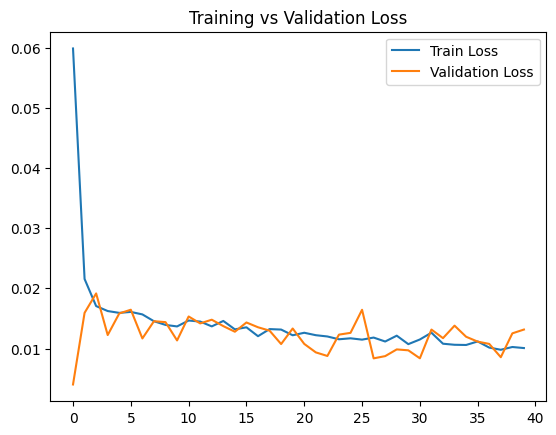

In [66]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

In [45]:
test1_preds.flatten().shape

(140,)

In [46]:
y_test1.shape

(140,)

In [67]:
test1_preds = model.predict(X_test1)

test1_errors = np.abs(test1_preds.flatten() - y_test1)

test1_threshold = test1_errors.mean() + 2 * test1_errors.std()

test1_anomaly = (test1_errors > test1_threshold).astype(int)

print("Threshold:", test1_threshold)
print("Total anomalies:", test1_anomaly.sum())

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Threshold: 0.2213426873787997
Total anomalies: 6


In [58]:
preds = model.predict(X_test)

errors = np.abs(preds.flatten() - y_test)

threshold = errors.mean() + 2 * errors.std()

anomaly = (errors > threshold).astype(int)

print("Threshold:", threshold)
print("Total anomalies:", anomaly.sum())

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Threshold: 0.1019721500379733
Total anomalies: 2


<Axes: ylabel='Count'>

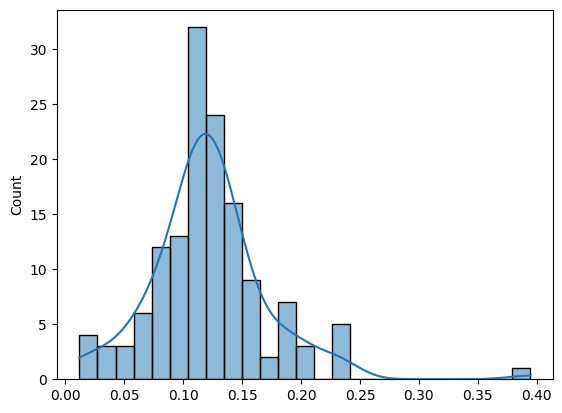

In [68]:
sns.histplot(test1_errors,kde=1)

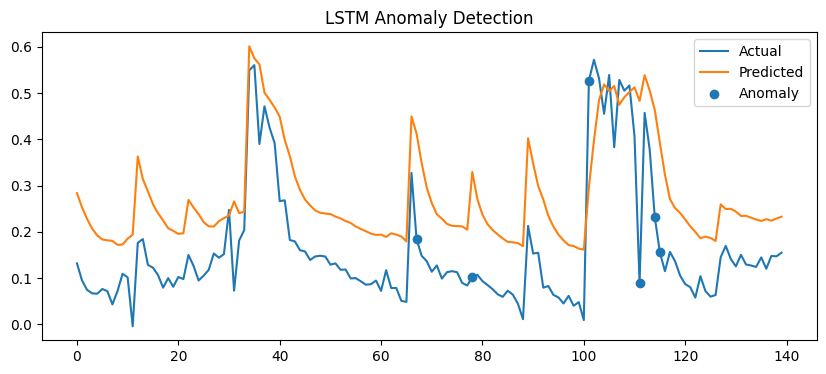

In [69]:
plt.figure(figsize=(10,4))

plt.plot(y_test1[:], label='Actual')
plt.plot(test1_preds.flatten()[:], label='Predicted')

anomaly_idx = np.where(test1_anomaly[:] == 1)[0]

plt.scatter(anomaly_idx, y_test1[:][anomaly_idx], label='Anomaly')

plt.legend()
plt.title("LSTM Anomaly Detection")
plt.show()

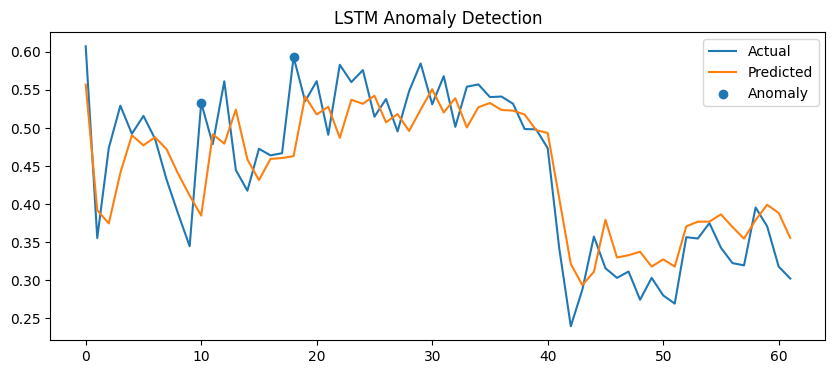

In [55]:
plt.figure(figsize=(10,4))

plt.plot(y_test[:100], label='Actual')
plt.plot(preds.flatten()[:100], label='Predicted')

anomaly_idx = np.where(anomaly[:100] == 1)[0]

plt.scatter(anomaly_idx, y_test[:100][anomaly_idx], label='Anomaly')

plt.legend()
plt.title("LSTM Anomaly Detection")
plt.show()